# DS/AI: Data Science Group Assignment - Great Cormorant

**Group name:** minecraft

**Student names & numbers:**
* Gabriel Chitarliev - 98920
* Aleksandar Manev - 99052
* Alexander Atanasov - 101953
* Dimitar Yosifov - 00099118

---

## Setup

**Import libraries**

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import contextily as cx
import numpy as np

**Load dataset**

In [16]:
df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False, parse_dates=["eventDate"])
df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

knmi = pd.read_csv(
    "KNMI.txt",
    comment="#",
    names=["STN", "YYYYMMDD", "FG", "TG", "TN", "TX", "SQ", "Q", "RH", "UG"],
    skipinitialspace=True,
)

df = df_sightings.merge(
    df_habitats,
    on=["decimalLatitude", "decimalLongitude"],
    how="inner",
)

In [17]:
df["month"] = df["eventDate"].dt.month
df["day_of_year"] = df["eventDate"].dt.day_of_year

In [18]:
knmi["date"] = pd.to_datetime(knmi["YYYYMMDD"], format="%Y%m%d")

knmi["RH"] = knmi["RH"].replace(-1, 0)
knmi["SQ"] = knmi["SQ"].replace(-1, 0)

for col in ["TG", "TN", "TX", "FG", "RH", "SQ"]:
    knmi[col] = knmi[col] / 10

knmi.head(5)

,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05


In [19]:
# df = df_sightings.merge(
#     df_habitats,
#     on=["decimalLatitude", "decimalLongitude"],
#     how="inner",
# )

STATIONS = {
    240: (52.318, 4.790),   # Schiphol
    260: (52.100, 5.180),   # De Bilt
    270: (53.224, 5.752),   # Leeuwarden
    280: (53.125, 6.585),   # Eelde
    290: (52.274, 6.891),   # Twenthe
    310: (51.442, 3.596),   # Vlissingen
    330: (51.992, 4.122),   # Hoek van Holland
    344: (51.962, 4.447),   # Rotterdam
    380: (50.906, 5.762),   # Maastricht
    391: (51.498, 6.197),   # Arcen
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

cells = df[["decimalLatitude", "decimalLongitude"]].drop_duplicates().reset_index(drop=True)

stn_ids  = np.array(list(STATIONS.keys()))
stn_lats = np.array([s[0] for s in STATIONS.values()])
stn_lons = np.array([s[1] for s in STATIONS.values()])

dist = haversine_km(
    cells["decimalLatitude"].values[:, None],
    cells["decimalLongitude"].values[:, None],
    stn_lats[None, :],
    stn_lons[None, :],
)
cells["STN"] = stn_ids[dist.argmin(axis=1)]

print("Grid cells per station:")
print(cells["STN"].value_counts().sort_index())
cells.head()
leftover = ["STN", "STN_x", "STN_y", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q", "date"]

df = df.drop(columns=[c for c in leftover if c in df.columns])

df = df.merge(cells, on=["decimalLatitude", "decimalLongitude"], how="left")

df = df.merge(
    knmi[["STN", "date", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]],
    left_on=["STN", "eventDate"],
    right_on=["STN", "date"],
    how="left",
).drop(columns=["date"])

Grid cells per station:
STN
240    198
260    345
270    286
280    306
290    266
310    160
330     59
344    202
380    120
391    207
Name: count, dtype: int64


In [20]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [21]:
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month
df['week'] = df['eventDate'].dt.isocalendar().week

In [22]:
df.to_parquet("cormorant_habitat_weather.parquet", index=False)

---

## 1. Business Understanding



**Business objective(s)**

- Balancing the conservation of the Great Cormorant with the economic viability of the Dutch inland fisheries and aquaculture sectors. The primary goal is to provide a data-driven framework that minimizes 'serious damage' to fish stocks and commercial yields through targeted management strategies and predictive impact modeling.


**Business success criteria**



**Data mining goal(s)**

- Use Latitude/Longitude data to identify "hotspots" where high cormorant density overlaps with high-value fishing/aquaculture zones

- Build a model to correlate cormorant sightings with actual fish stock depletion or wounding rates.

**Data mining success criteria**

- The model identifies high-impact zones with a Precision of >80%, ensuring that management resources are not wasted on low-impact areas.

## 2. Data Understanding


In [23]:
print("Shape:", knmi.shape)
knmi.head(11)

Shape: (59589, 11)


,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05
5,240,20100106,3.4,-2.8,-6.6,0.3,5.5,449.0,2.8,95.0,2010-01-06
6,240,20100107,2.7,-4.8,-11.5,-2.4,4.7,376.0,0.0,94.0,2010-01-07
7,240,20100108,4.0,-5.7,-13.8,-2.2,2.1,246.0,0.0,95.0,2010-01-08
8,240,20100109,10.0,-1.8,-4.5,-0.4,0.0,198.0,0.6,88.0,2010-01-09
9,240,20100110,7.0,-0.1,-0.6,0.4,0.0,80.0,1.7,95.0,2010-01-10


In [24]:
df.head(3)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0,2010,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0,2010,53


In [25]:
print("Shape:", df.shape)
df.head(3)

Shape: (12558756, 28)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0,2010,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0,2010,53


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 28 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        int64         
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  month                      int32         
 16  day_of_year                int32         
 17

In [27]:
print(df_sightings["Phalacrocorax carbo"].unique())

<ArrowStringArray>
[      '0',       '1',       '2',       '4',       '3',       '5',       '6',
       '7',      '10',      '11',      '20',       '9',       '8',      '15',
      '17',      '16',      '12',      '14',      '24',      '22',      '25',
      '21',      '27',      '18',      '50',      '13',      '28',      '26',
      '35',      '23',      '19',      '43',      '56',      '36',      '30',
      '41',      '62',      '32',      '37',      '34',      '31',      '51',
      '67',      '29',      '42',      '55',     '109',      '45',      '57',
      '58',      '38',      '33',      '63',      '-1', 'unknown']
Length: 55, dtype: str


In [28]:
present_count = (df['Phalacrocorax carbo'] > 0).sum()
print(f'Cormorant is present = {present_count}')

Cormorant is present = 459897


In [29]:
present_count = (df['Phalacrocorax carbo'] == 0).sum()
print(f'Cormorant is not present = {present_count}')

Cormorant is not present = 12098859


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 28 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        int64         
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  month                      int32         
 16  day_of_year                int32         
 17

In [31]:
df.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0,2010,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0,2010,53
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0,2010,1
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0,2010,1


In [32]:
df.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.4,-2.4,7.2,0.0,2.2,90.0,0.5,126.0,2025,52
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,...,0.3,-3.2,4.4,0.0,1.4,97.0,1.7,198.0,2025,52
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,...,5.2,1.1,7.4,0.2,3.3,83.0,0.5,141.0,2025,1
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.2,-2.1,6.4,0.1,3.0,70.0,5.1,295.0,2025,1
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,...,4.0,-1.1,7.4,0.1,5.2,89.0,1.7,195.0,2025,1


In [33]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
decimalLatitude,12558756.0,52.23006,50.75,51.7,52.2,52.8,53.5,0.660521
decimalLongitude,12558756.0,5.532783,3.35,4.9,5.65,6.2,7.2,0.874886
eventDate,12558756,2017-12-31 11:59:59.999999,2010-01-01 00:00:00,2013-12-31 18:00:00,2017-12-31 12:00:00,2021-12-31 06:00:00,2025-12-31 00:00:00,NaN
total_observations,12558756.0,8.067763,0.0,0.0,1.0,6.0,100040.0,39.125017
speciesgroup_observations,12558756.0,4.330658,0.0,0.0,0.0,2.0,2779.0,16.067937
Phalacrocorax carbo,12558756.0,0.051434,0.0,0.0,0.0,0.0,109.0,0.336498
agricultural,12558756.0,9.452277,0.0,5.3484,10.5682,13.8008,18.1046,5.147907
built,12558756.0,2.404833,0.0,0.7667,1.5599,3.2916,14.3538,2.419758
coast,12558756.0,1.302932,0.0,0.0,0.0,0.0,19.3487,3.970215
forest,12558756.0,1.621184,0.0,0.1494,0.7092,2.0364,16.9985,2.385737


In [34]:
print(df[(df['Phalacrocorax carbo'] > 5) & (df['wetland'] == 0)]['main_habitat'].value_counts())

main_habitat
coast           655
built           154
agricultural    138
water            70
other            11
forest            2
Name: count, dtype: int64


<Axes: xlabel='decimalLongitude', ylabel='decimalLatitude'>

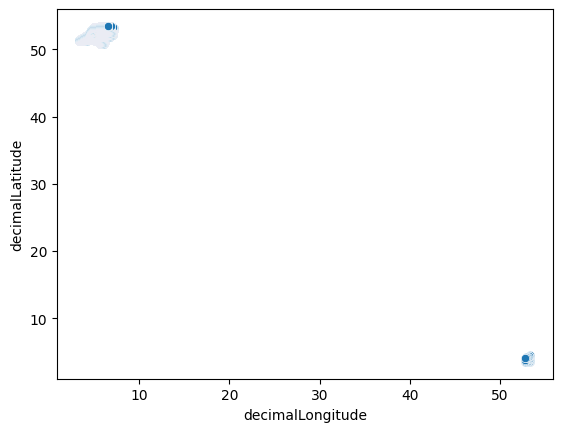

In [35]:
sns.scatterplot(data=df_sightings, x='decimalLongitude', y='decimalLatitude')

<Axes: xlabel='decimalLongitude', ylabel='decimalLatitude'>

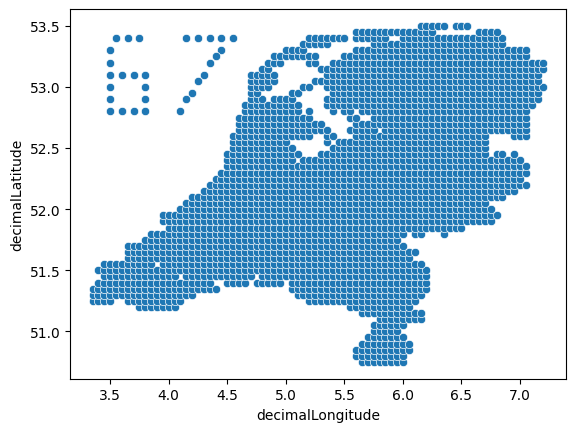

In [36]:
sns.scatterplot(data=df_habitats, x='decimalLongitude', y='decimalLatitude')

### Heatmap of Observations 2020-2025
This heatmap shows the observations per grid cell found inside the Netherlands in specific grid cells

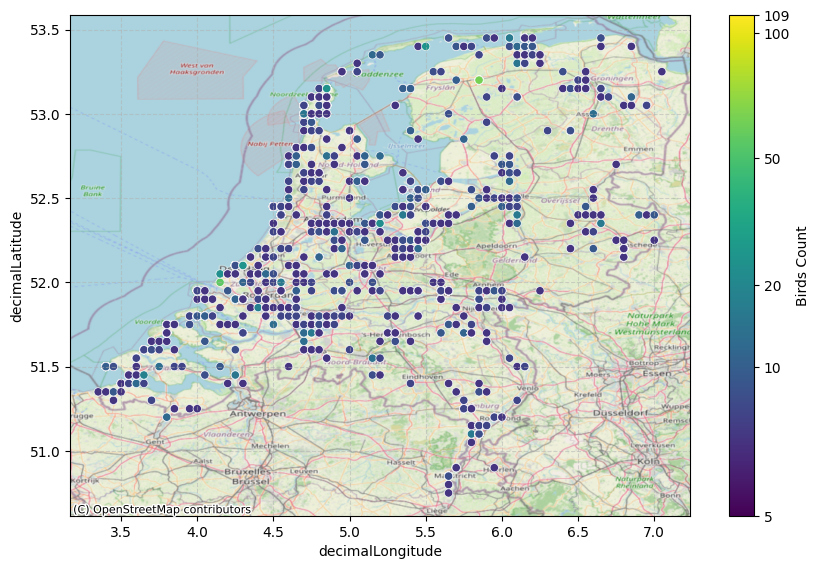

In [37]:
dfX = df[(df['Phalacrocorax carbo'] > 5) & (df['year'] >= 2020) & (df['year'] <= 2025) ]
my_norm = colors.PowerNorm(gamma=0.4, vmin=5, vmax=109)

plt.figure(figsize=(10, 6.5))
# 1. Plot (notice legend=False)
ax = sns.scatterplot(
    data=dfX, x='decimalLongitude', y='decimalLatitude', 
    hue='Phalacrocorax carbo', hue_norm=my_norm, palette='viridis', legend=False
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik)
# 2. Add a colorbar and force your exact numbers onto it
sm = plt.cm.ScalarMappable(cmap='viridis', norm=my_norm)
cbar = plt.colorbar(sm, ax=ax, label='Birds Count')
cbar.set_ticks([5, 10, 20, 50, 100, 109])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Average monthly observations of cormorants
Cormorants are migratory. We expect a clear seasonal pattern here - this is usually one of the strongest signals in any bird-sighting dataset.
Explains that they are winter migratory birds. Since the netherlands is not as cold during winter cormorants from northern countries arrive here and
increase the population. Since they prefer cold weather but not too cold it is expected to see a decrease in the population during the summer months.

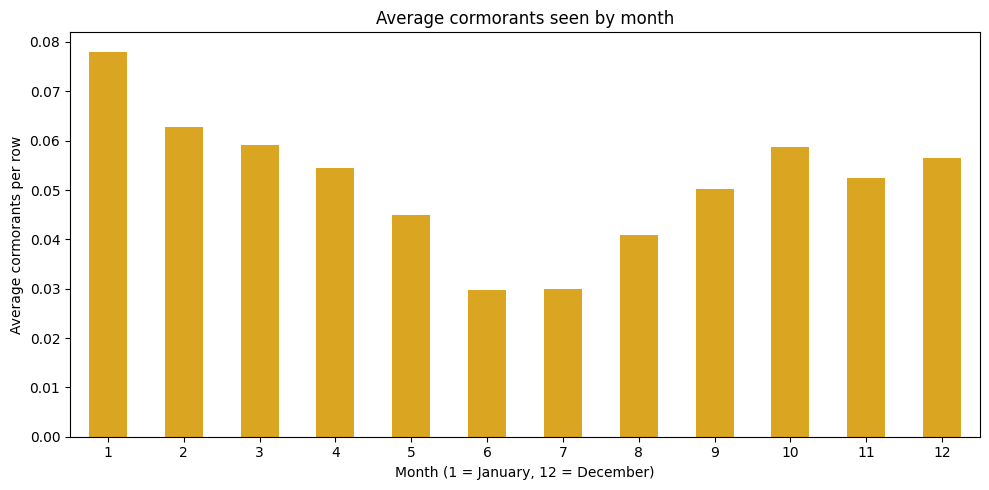

In [38]:
month_means = df.groupby("month")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
month_means.plot(kind="bar", color="goldenrod")
plt.title("Average cormorants seen by month")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cormorants seen by day of year

Same idea, but at daily resolution. Catches finer migration patterns inside each month.

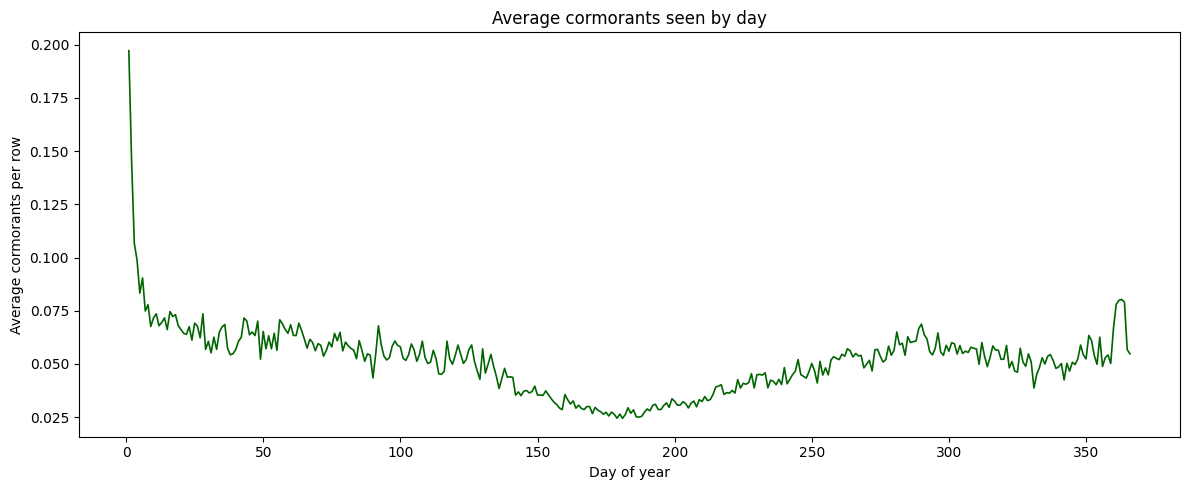

In [39]:
doy_means = df.groupby("day_of_year")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(12, 5))
doy_means.plot(color="darkgreen", linewidth=1.2)
plt.title("Average cormorants seen by day")
plt.xlabel("Day of year")
plt.ylabel("Average cormorants per row")
plt.tight_layout()
plt.show()

### Cormorants seen by year


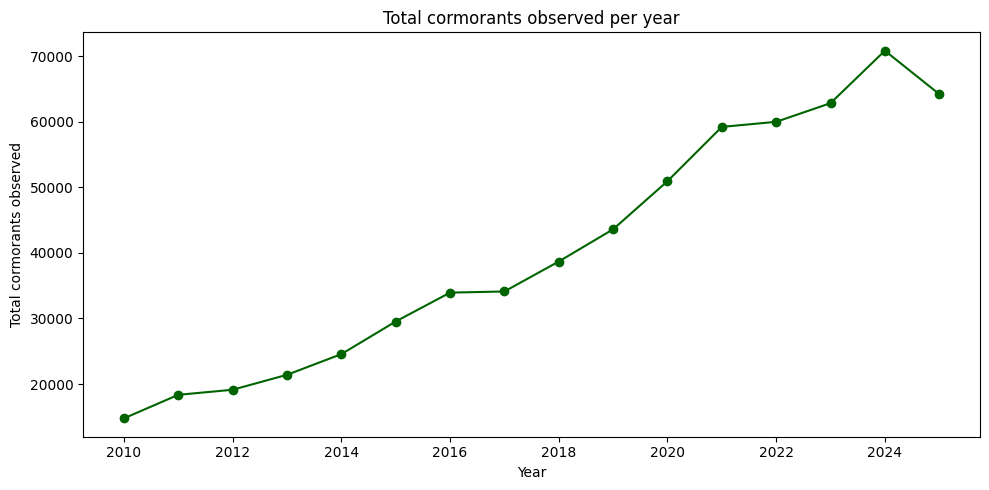

In [40]:
yearly = df.groupby(df["eventDate"].dt.year)["Phalacrocorax carbo"].sum()

plt.figure(figsize=(10, 5))
yearly.plot(kind="line", marker="o", color="darkgreen")
plt.title("Total cormorants observed per year")
plt.xlabel("Year")
plt.ylabel("Total cormorants observed")
plt.tight_layout()
plt.show()

### Cormorants per month over time


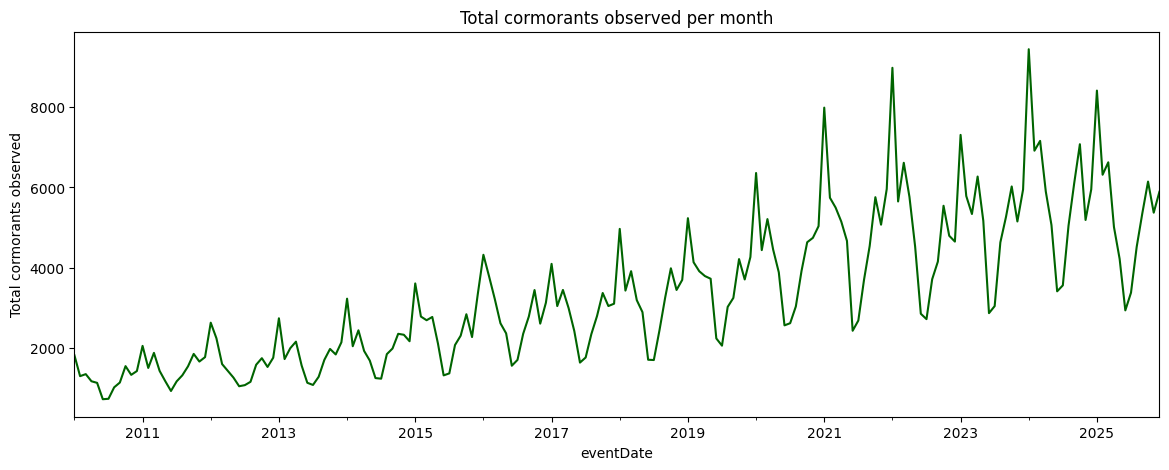

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df
# df_plot = pd.read_parquet("bird_habitats_weather.parquet")

monthly = df_plot.groupby(df_plot["eventDate"].dt.to_period("M"))["Phalacrocorax carbo"].sum()

monthly.plot(figsize=(14, 5), color="darkgreen")
plt.title("Total cormorants observed per month")
plt.ylabel("Total cormorants observed")
plt.show()

### Faceted barchart
This barchart shows per different bins 6-10, 11-20, 21-50, 50+ what the count of observations in the given range is based on main habitat

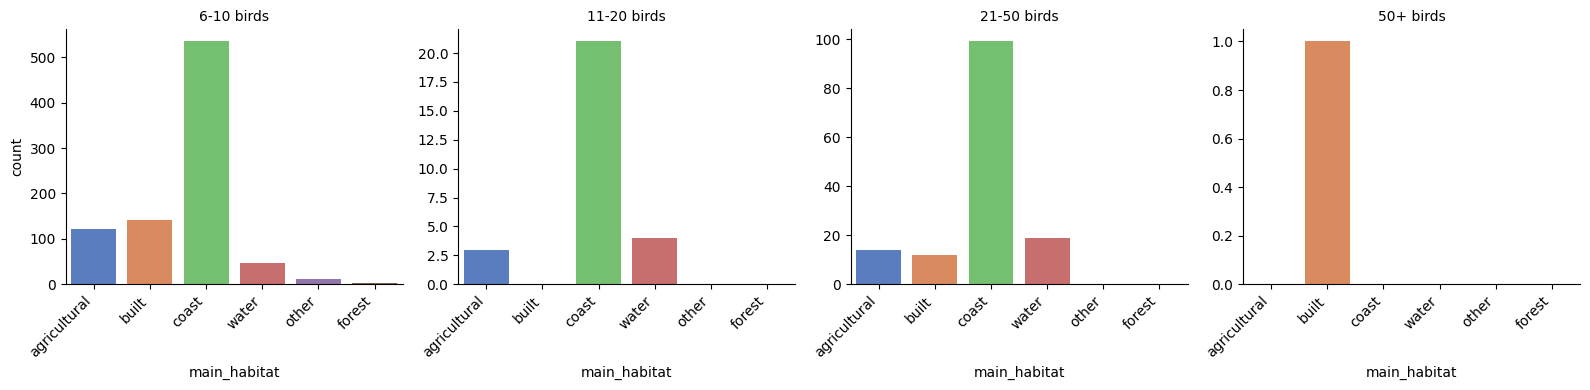

In [42]:
# 1. Filter out wetlands and bucket the counts
df_non_wetland = df[df['wetland'] == 0].copy()
df_non_wetland['bird_brackets'] = pd.cut(
    df_non_wetland['Phalacrocorax carbo'], 
    bins=[5, 10, 20, 50, float('inf')], 
    labels=['6-10 birds', '11-20 birds', '21-50 birds', '50+ birds']
)
df_filtered = df_non_wetland.dropna(subset=['bird_brackets'])

# 2. Use catplot to split into separate subplots side-by-side
g = sns.catplot(
    data=df_filtered,
    x='main_habitat',
    hue='main_habitat',
    col='bird_brackets',    # Creates a separate plot for each bracket
    kind='count',
    sharey=False,           # CRITICAL: Gives each plot its own Y-axis scale!
    palette='muted',
    height=4,
    aspect=1.0
)

# Rotate habitat labels so they don't overlap
g.set_xticklabels(rotation=45, ha='right')
g.set_titles("{col_name}") # Cleans up the subplot titles

plt.tight_layout()
plt.show()

### Log scaled box plot of total observations

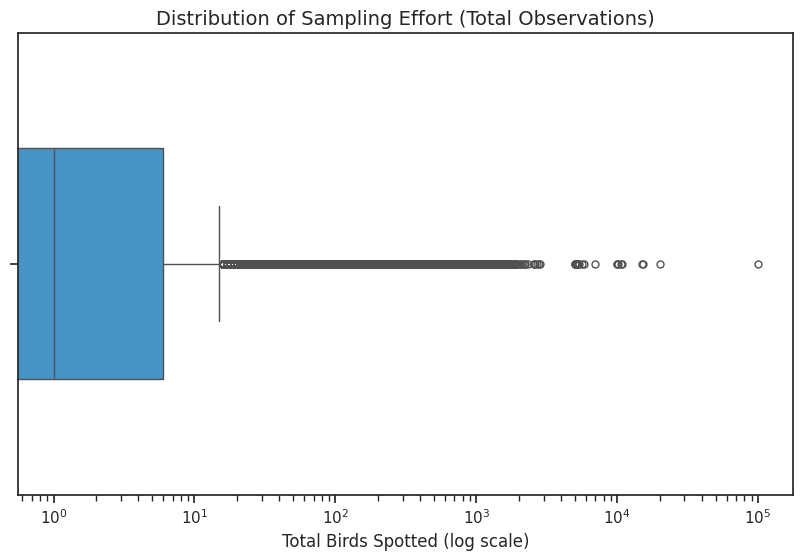

In [43]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

ax = sns.boxplot(
    x=df['total_observations'], 
    color='#3498db',
    width=0.5,
    fliersize=5  
)
ax.set_xscale("log")

plt.title('Distribution of Sampling Effort (Total Observations)', fontsize=14)
plt.xlabel('Total Birds Spotted (log scale)', fontsize=12)

plt.show()

### Correlation matrix logic
Here we define our columns and a function that makes the correlation matrices since they are basically repeating code with different parameters

In [44]:

# Split the variables into groups so we get smaller, easier-to-read matrixes
bird_cols    = ["Phalacrocorax carbo", "total_observations", "speciesgroup_observations"]
habitat_cols = ["agricultural", "built", "coast", "forest", "water", "wetland", "sand/heather"]
weather_cols = ["TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]

pretty = {
    "TG": "Mean temp",
    "TN": "Min temp",
    "TX": "Max temp",
    "RH": "Rain (mm)",
    "FG": "Wind (m/s)",
    "UG": "Humidity (%)",
    "SQ": "Sunshine (h)",
    "Q":  "Solar radiation",
}

def plot_corr(cols, title, method):
    corr = df[cols].corr(method=method).rename(index=pretty, columns=pretty)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, linewidths=0.3, annot_kws={"size": 8}, mask=mask)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### Bird Sightings to Habitats Pearson correlation matrix 

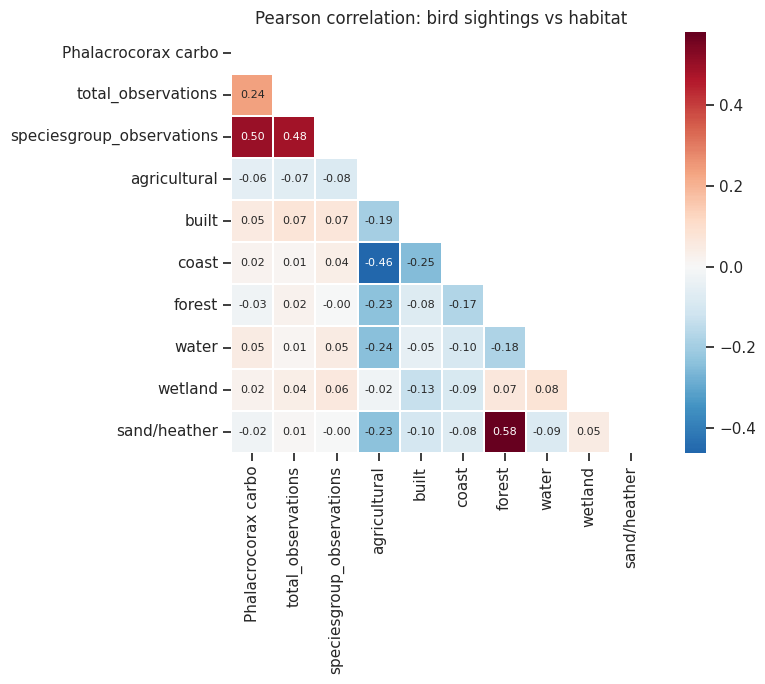

In [47]:
plot_corr(bird_cols + habitat_cols, "Pearson correlation: bird sightings vs habitat", 'pearson')

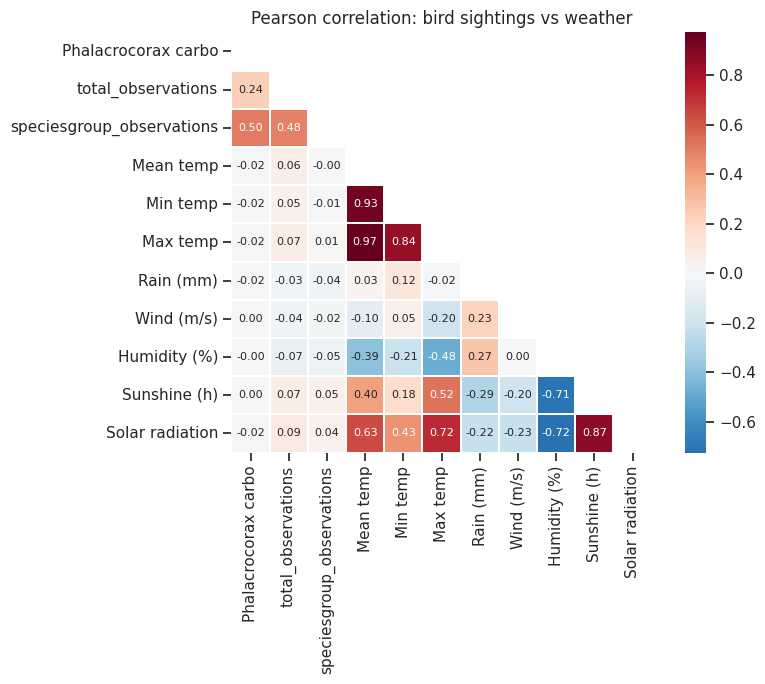

In [48]:

plot_corr(bird_cols + weather_cols, "Pearson correlation: bird sightings vs weather", 'pearson')

### Bird Sightings to Habitat Spearman correlation matrix

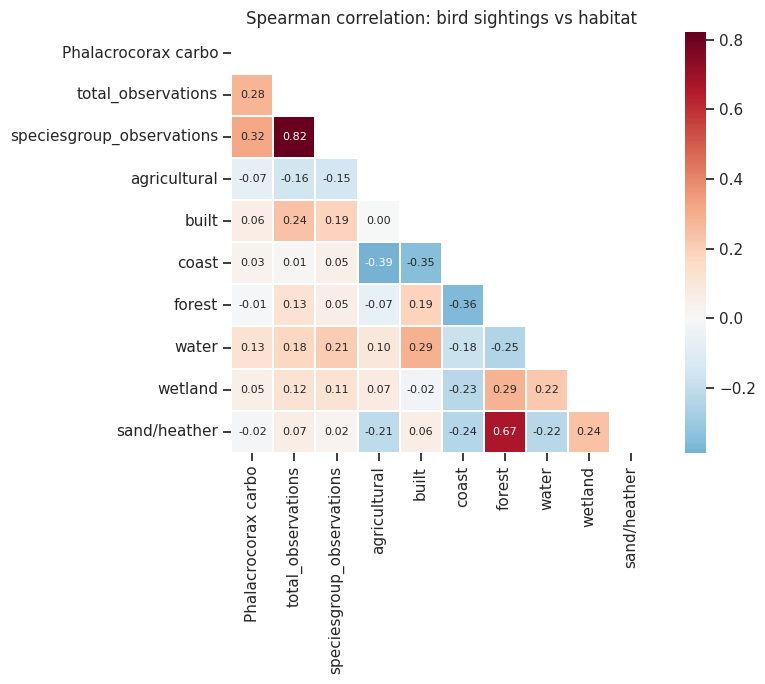

In [49]:

plot_corr(bird_cols + habitat_cols, "Spearman correlation: bird sightings vs habitat", "spearman")

### Bird Sightings to Weather Spearman correlation matrix

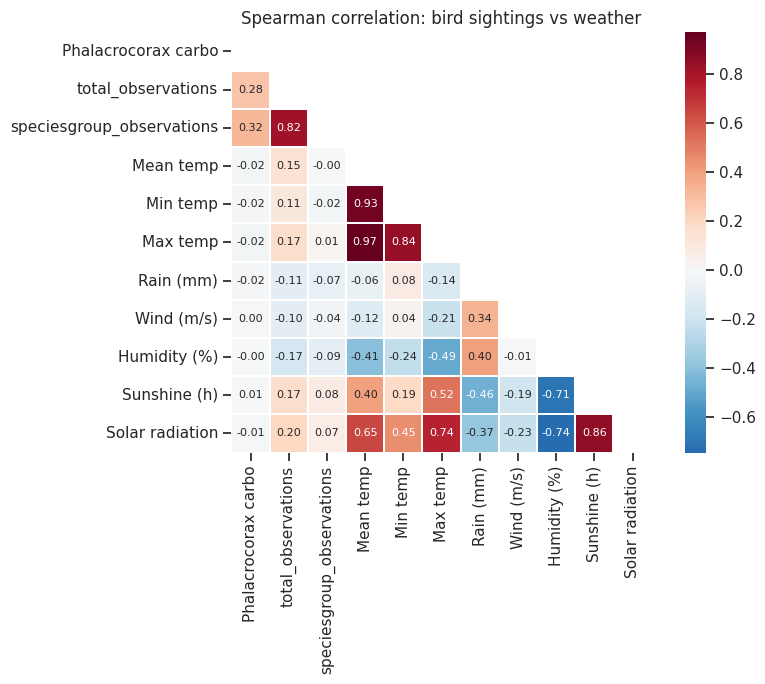

In [50]:

plot_corr(bird_cols + weather_cols, "Spearman correlation: bird sightings vs weather", "spearman")

### Cormorants seen vs temperature

We split the daily mean temperature (TG) into 2 °C ranges and plot the average number of cormorants seen per row in each range.

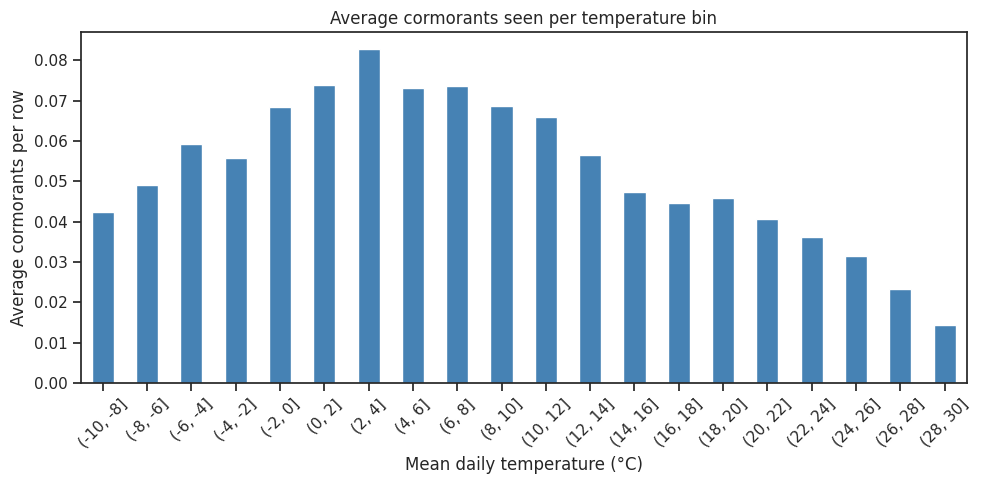

In [ ]:
plot_df = df[["TG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["TG_bin"] = pd.cut(plot_df["TG"], bins=range(-10, 32, 2))
temp_means = plot_df.groupby("TG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
temp_means.plot(kind="bar", color="steelblue")
plt.title("Average cormorants seen per temperature bin")
plt.xlabel("Mean daily temperature (°C)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cormorants seen vs humidity

Same idea, but binned by daily mean humidity 

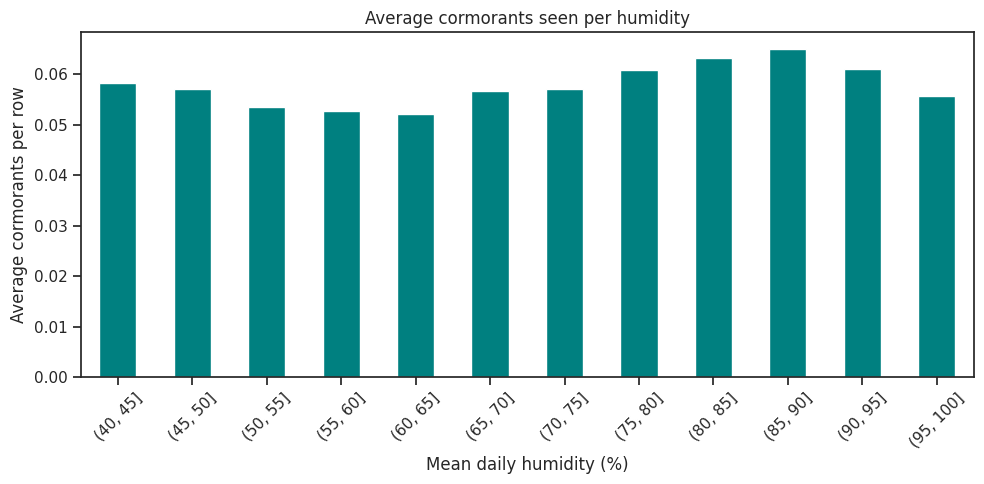

In [ ]:
plot_df = df[["UG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["UG_bin"] = pd.cut(plot_df["UG"], bins=range(40, 101, 5))
hum_means = plot_df.groupby("UG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
hum_means.plot(kind="bar", color="teal")
plt.title("Average cormorants seen per humidity")
plt.xlabel("Mean daily humidity (%)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cormorants seen vs rain

Group days into 4 buckets - none / light / moderate / heavy - and check average sightings per bucket.

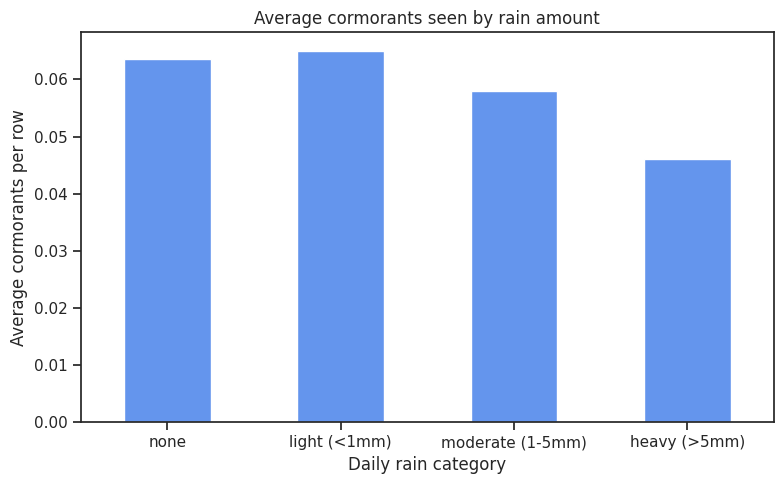

In [ ]:
plot_df = df[["RH", "Phalacrocorax carbo"]].dropna().copy()
plot_df["rain_cat"] = pd.cut(
    plot_df["RH"],
    bins=[-0.1, 0, 1, 5, 1000],
    labels=["none", "light (<1mm)", "moderate (1-5mm)", "heavy (>5mm)"],
)
rain_means = plot_df.groupby("rain_cat", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(8, 5))
rain_means.plot(kind="bar", color="cornflowerblue")
plt.title("Average cormorants seen by rain amount")
plt.xlabel("Daily rain category")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cormorants seen vs wind

Binned by daily mean wind speed (`FG`, in m/s).

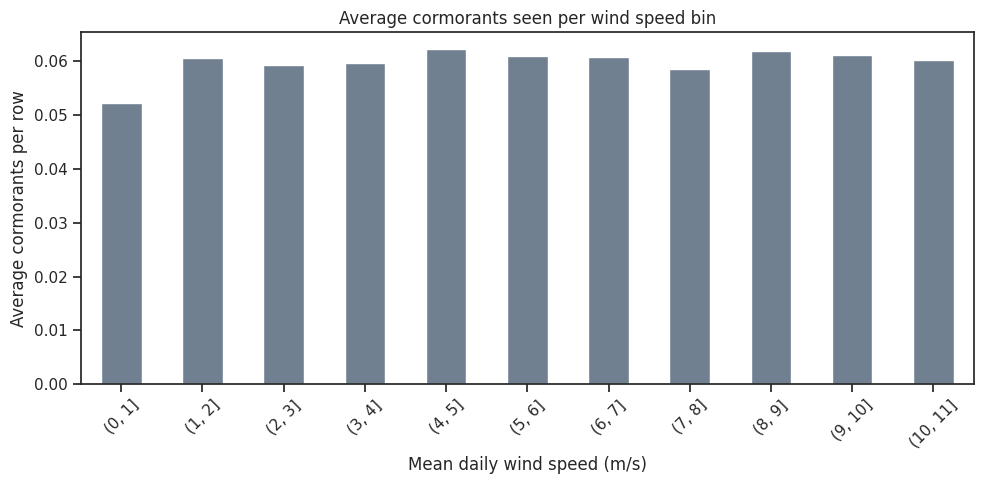

In [ ]:
plot_df = df[["FG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["FG_bin"] = pd.cut(plot_df["FG"], bins=np.arange(0, 12, 1))
wind_means = plot_df.groupby("FG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
wind_means.plot(kind="bar", color="slategray")
plt.title("Average cormorants seen per wind speed bin")
plt.xlabel("Mean daily wind speed (m/s)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Min Max scaling and forward fill

Min Max Scling:
Our tree models don't need scaling, so we show it on a new wine dataset.MinMax scling puts a column into a 0-1 ranges.We scaled proline and hue beacuse before, they were on very different scales.After scaling both are between 0–1, so they can be compared fairly. Scaling like this matters for distance- and gradient-based models, but not for our models.

In [51]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_wine

wine_df=load_wine(as_frame=True).frame
wine_df.describe().drop('count').round(2).T

,mean,std,min,25%,50%,75%,max
alcohol,13.00,0.81,11.03,12.36,13.05,13.68,14.83
malic_acid,2.34,1.12,0.74,1.60,1.87,3.08,5.80
ash,2.37,0.27,1.36,2.21,2.36,2.56,3.23
alcalinity_of_ash,19.49,3.34,10.60,17.20,19.50,21.50,30.00
magnesium,99.74,14.28,70.00,88.00,98.00,107.00,162.00
total_phenols,2.30,0.63,0.98,1.74,2.36,2.80,3.88
flavanoids,2.03,1.00,0.34,1.20,2.13,2.88,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.27,0.34,0.44,0.66
proanthocyanins,1.59,0.57,0.41,1.25,1.56,1.95,3.58
color_intensity,5.06,2.32,1.28,3.22,4.69,6.20,13.00


In [52]:
wine_df.head(5)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [53]:
wine_df[['proline_scaled','hue_scaled']] = MinMaxScaler().fit_transform(wine_df[['proline','hue']])
wine_df[['proline','hue', 'proline_scaled', 'hue_scaled']].describe().drop('count').round(2).T

,mean,std,min,25%,50%,75%,max
proline,746.89,314.91,278.00,500.50,673.50,985.00,1680.00
hue,0.96,0.23,0.48,0.78,0.96,1.12,1.71
proline_scaled,0.33,0.22,0.00,0.16,0.28,0.50,1.00
hue_scaled,0.39,0.19,0.00,0.25,0.39,0.52,1.00


In [54]:
from sklearn.impute import SimpleImputer

imp=SimpleImputer(strategy='mean')
df['TG_filled'] = imp.fit_transform(df[['TG']])

print("missing before:", df['TG'].isna().sum())
print("missing after:", df['TG_filled'].isna().sum())
print("mean value:", round(df['TG'].mean(), 2))

missing before: 21113
missing after: 0
mean value: 10.88


In [55]:
wine_df['color_intensity_minmax']=MinMaxScaler().fit_transform(wine_df[['color_intensity']])
wine_df['color_intensity_log'] =np.log1p(wine_df['color_intensity'])
wine_df[['color_intensity', 'color_intensity_minmax', 'color_intensity_log']].describe()

,color_intensity,color_intensity_minmax,color_intensity_log
count,178.000000,178.000000,178.000000
mean,5.058090,0.322363,1.731880
std,2.318286,0.197806,0.373143
min,1.280000,0.000000,0.824175
25%,3.220000,0.165529,1.439827
50%,4.690000,0.290956,1.738709
75%,6.200000,0.419795,1.974081
max,13.000000,1.000000,2.639057


In [56]:
wine_df[['color_intensity', 'color_intensity_log']].describe()

,color_intensity,color_intensity_log
count,178.000000,178.000000
mean,5.058090,1.731880
std,2.318286,0.373143
min,1.280000,0.824175
25%,3.220000,1.439827
50%,4.690000,1.738709
75%,6.200000,1.974081
max,13.000000,2.639057


## 3. Data preparation

### Dataset engineering

Currently the dataset holds information about the sightings of the bird for each day at a specific place. Giving this to a model would overwhelm it due to the heavy class imbalance. A possible way to resolve this issue is to aggregate the sightings for a week by that week in a specific place.

In [57]:
grouped = df.groupby(['year','week','decimalLatitude','decimalLongitude'])
result = grouped.agg(weekly_cormorant_observations =('Phalacrocorax carbo', 'sum'),
                      weekly_speciesgroup_observations = ('speciesgroup_observations','sum'))

Once calculated, the result needs to be converted into a Dataframe.

In [58]:
df_weekly_sightings = result.reset_index()

In [59]:
display(df_weekly_sightings)

,year,week,decimalLatitude,decimalLongitude,weekly_cormorant_observations,weekly_speciesgroup_observations
0,2010,1,50.75,5.65,0,1
1,2010,1,50.75,5.70,0,2
2,2010,1,50.75,5.75,0,0
3,2010,1,50.75,5.80,0,2
4,2010,1,50.75,5.85,0,0
...,...,...,...,...,...,...
1798708,2025,52,53.50,6.30,0,0
1798709,2025,52,53.50,6.35,0,1
1798710,2025,52,53.50,6.45,0,0
1798711,2025,52,53.50,6.50,0,0


In [60]:
df_weekly_sightings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1798713 entries, 0 to 1798712
Data columns (total 6 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   year                              int32  
 1   week                              UInt32 
 2   decimalLatitude                   float64
 3   decimalLongitude                  float64
 4   weekly_cormorant_observations     int64  
 5   weekly_speciesgroup_observations  int64  
dtypes: UInt32(1), float64(2), int32(1), int64(2)
memory usage: 70.3 MB


Statistics from the aggregated dataset

In [61]:
present_count = (df_weekly_sightings['weekly_cormorant_observations'] > 0).sum()
print(f'Cormorant is present = {present_count}')

Cormorant is present = 281212


In [62]:
not_present_count = (df_weekly_sightings['weekly_cormorant_observations'] == 0).sum()
print(f'Cormorant is not present = {not_present_count}')

Cormorant is not present = 1517501


Adding additional features into the dataset for model training.

In [63]:
df_weekly_sightings_and_habitats = df_weekly_sightings.merge(
    df_habitats,
    on=["decimalLatitude", "decimalLongitude"],
    how="inner",
)

In [64]:
df_model_filtered = df_weekly_sightings_and_habitats[df_weekly_sightings_and_habitats['year'] > 2019]

In [65]:
present_count = (df_model_filtered['weekly_cormorant_observations'] > 0).sum()
print(f'Cormorant is present = {present_count}')

Cormorant is present = 145168


In [66]:
not_present_count = (df_model_filtered['weekly_cormorant_observations'] == 0).sum()
print(f'Cormorant is not present = {not_present_count}')

Cormorant is not present = 529618


In [67]:
df_model_filtered.head(5)

,year,week,decimalLatitude,decimalLongitude,weekly_cormorant_observations,weekly_speciesgroup_observations,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
1123927,2020,1,50.75,5.65,1,11,1.7747,0.0568,0.0,0.0616,0.0582,0.0000,0.4688,0.0,agricultural
1123928,2020,1,50.75,5.70,0,26,9.9751,2.6012,0.0,0.9364,1.5790,0.0000,0.1626,0.0,agricultural
1123929,2020,1,50.75,5.75,0,1,7.8028,0.8299,0.0,0.6983,0.4834,0.0000,0.0018,0.0,agricultural
1123930,2020,1,50.75,5.80,0,8,13.2636,1.1357,0.0,0.8595,0.6516,0.0000,0.0045,0.0,agricultural
1123931,2020,1,50.75,5.85,0,12,9.3689,0.5808,0.0,4.0774,0.8342,0.0252,0.0121,0.0,agricultural


In [68]:
df_model_filtered.info()

<class 'pandas.DataFrame'>
RangeIndex: 674786 entries, 1123927 to 1798712
Data columns (total 15 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   year                              674786 non-null  int32  
 1   week                              674786 non-null  UInt32 
 2   decimalLatitude                   674786 non-null  float64
 3   decimalLongitude                  674786 non-null  float64
 4   weekly_cormorant_observations     674786 non-null  int64  
 5   weekly_speciesgroup_observations  674786 non-null  int64  
 6   agricultural                      674786 non-null  float64
 7   built                             674786 non-null  float64
 8   coast                             674786 non-null  float64
 9   forest                            674786 non-null  float64
 10  other                             674786 non-null  float64
 11  sand/heather                      674786 non-null  float

### Creating the present target

In [69]:
df_model_filtered['present'] = (df_model_filtered['weekly_cormorant_observations'] > 0).astype(int)

We order the data by year so that the train-test can split it in a time series manner.

In [70]:
df_model_filtered = df_model_filtered.sort_values('year')

## 4. Modelling

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor


### Train test split

In [54]:
X = df_model_filtered.drop(columns=['weekly_cormorant_observations','main_habitat','present'])
y = df_model_filtered['present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, shuffle=False)

### Random Forest Classifier

In [55]:

baseModel = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    min_samples_leaf=50,
    max_features="log2",
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

baseModel.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [56]:
y_pred = baseModel.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.83      0.88    171965
           1       0.58      0.81      0.68     50715

    accuracy                           0.82    222680
   macro avg       0.76      0.82      0.78    222680
weighted avg       0.86      0.82      0.83    222680



#### ROC-AUC Curve

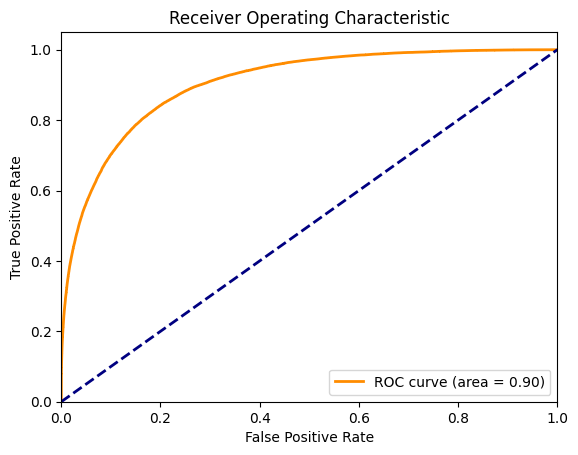

In [57]:
y_probs = baseModel.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#### Classification Confusion Matrix

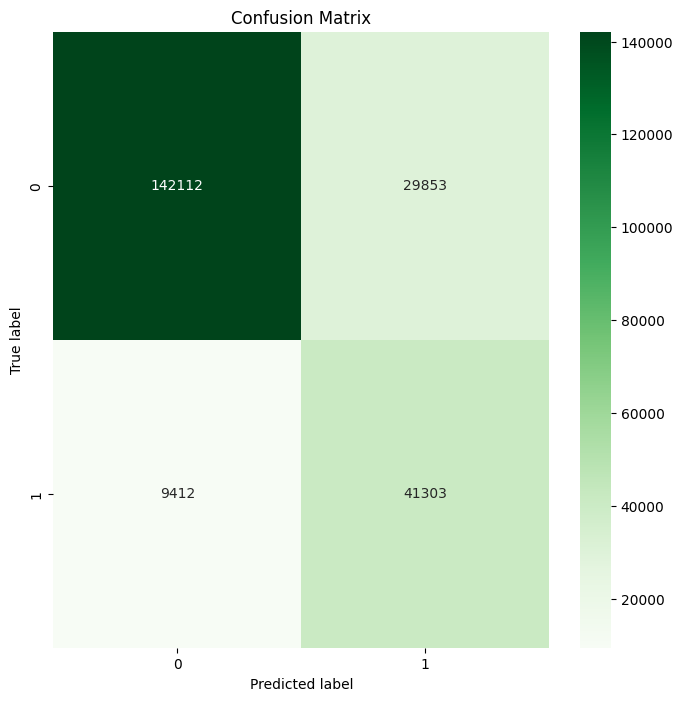

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

### Two stage hurdle model train-test split

the split differs from the one used for classification since we are changing the target

In [59]:
X = df_model_filtered.drop(columns=['weekly_cormorant_observations','main_habitat','present'])
y = df_model_filtered['weekly_cormorant_observations']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, shuffle=False)

### Two Stage Hurdle model

In [60]:
from sklearn.base import BaseEstimator, RegressorMixin

class HurdleModel(BaseEstimator, RegressorMixin):
    def __init__(self, classifier=None, regressor=None):
        self.classifier = (
            RandomForestClassifier() if classifier is None else classifier
        )
        self.regressor = (
            RandomForestRegressor() if regressor is None else regressor
        )
    def fit(self, X, y):
        y_boolean = (y > 0).astype(int)
        self.classifier.fit(X,y_boolean)

        positive_mask = y > 0
        if positive_mask.sum() > 0:
            X_positive = X[positive_mask]
            y_positive = y[positive_mask]
            self.regressor.fit(X_positive,y_positive)
        
        return self
    def predict_classifier(self, X):
        return self.classifier.predict(X)
    def predict_regression(self, X):
        return self.regressor.predict(X)
    def predict(self, X):
        classifier_pred = self.classifier.predict(X)

        regression_prediction = self.regressor.predict(X)

        return classifier_pred * regression_prediction

In [61]:
model = HurdleModel(
    classifier=RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    min_samples_leaf=50,
    max_features="log2",
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
   ),
   regressor=RandomForestRegressor(
       n_estimators=150,
       max_depth=10,
       min_samples_leaf=3,
       random_state=42,
       n_jobs=-1
   )
)

model.fit(X_train,y_train)

,classifier,RandomForestC...ndom_state=42)
,regressor,RandomForestR...ndom_state=42)
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0


statisstics for hurdle model

In [62]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict_regression(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f'MAE:{mae: .2f}')

MAE: 1.25


In [63]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f'MAE:{mae: .2f}')

MAE: 0.53


#### Plotting two stage hurdle model predictions vs actual observations count

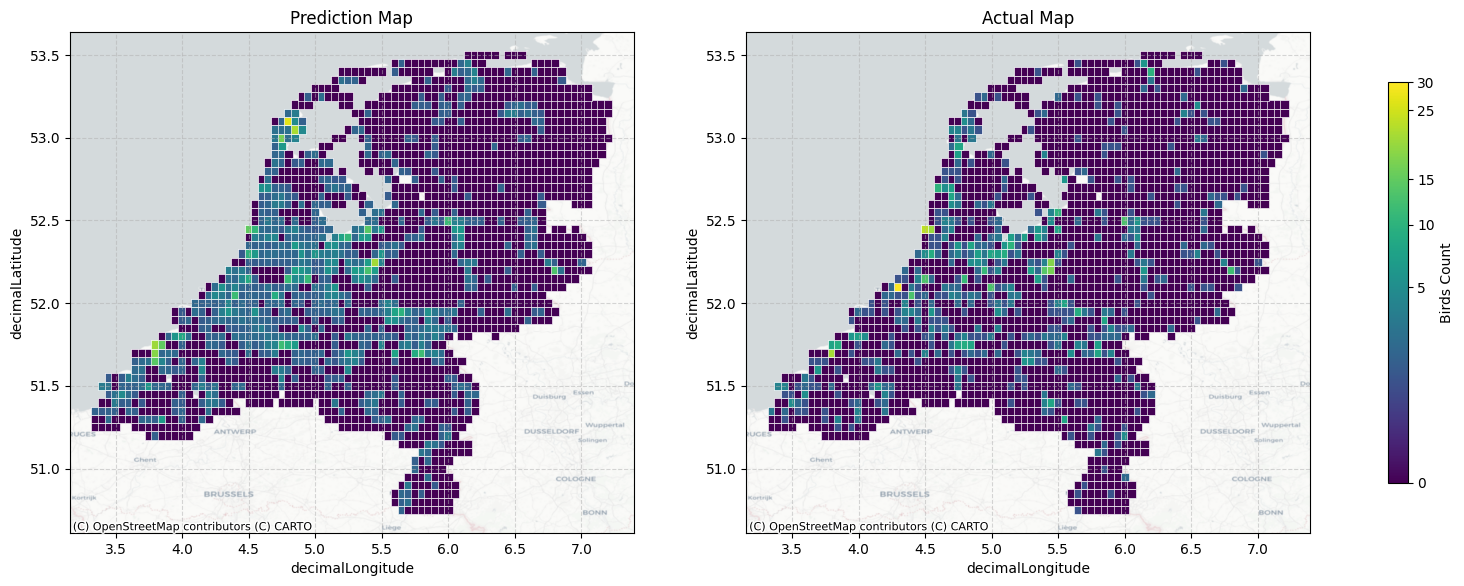

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.5))

my_norm = colors.PowerNorm(gamma=0.4, vmin=0, vmax=30)

sns.scatterplot(
    data=X_test, x='decimalLongitude', y='decimalLatitude', 
    hue=y_pred, hue_norm=my_norm, palette='viridis', legend=False, marker='s', 
    ax=axes[0] 
)
cx.add_basemap(axes[0], crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
axes[0].set_title("Prediction Map")
axes[0].grid(True, linestyle='--', alpha=0.5)


sns.scatterplot(
    data=X_test, x='decimalLongitude', y='decimalLatitude', 
    hue=y_test, hue_norm=my_norm, palette='viridis', legend=False, marker='s', 
    ax=axes[1]
)
cx.add_basemap(axes[1], crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
axes[1].set_title("Actual Map")
axes[1].grid(True, linestyle='--', alpha=0.5)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=my_norm)
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), label='Birds Count', shrink = 0.8)
cbar.set_ticks([0, 5, 10, 15, 25, 30])

plt.show()

---

### crazy burger model

In [65]:
def burger_model(row): 
    return 0

In [66]:
df_copy = df_model_filtered.copy()
df_copy['present'] = (df_copy['weekly_cormorant_observations'] > 0).astype(int)
df_copy['predicted_present'] = df_copy.apply(lambda row: burger_model(row), axis=1)

y_true = df_copy["present"]
y_pred = df_copy['predicted_present']

In [67]:
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.78      1.00      0.88    529618
           1       0.00      0.00      0.00    145168

    accuracy                           0.78    674786
   macro avg       0.39      0.50      0.44    674786
weighted avg       0.62      0.78      0.69    674786



/home/alex/year2/DS_AI/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alex/year2/DS_AI/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alex/year2/DS_AI/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 